# Preprocessing Workflow

Clean preprocessing notebook for multiple earthquake catalogs: parse raw catalogs, build processed CSV files, and run basic diagnostics.

## 1) Setup

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import torch


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / 'src').exists() and (candidate / 'data').exists():
            return candidate
    raise FileNotFoundError("Cannot find project root containing src/ and data/.")


PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / 'data'
CHINA_SHP_PATH = DATA_DIR / 'ne_10m_admin_0_countries' / 'ne_10m_admin_0_countries.shp'

from src.data.preprocessing import (
    process_synthetic_catlog,
    process_recast_catalog,
    load_and_filter_catalog,
    plot_dt_distributions,
)
from src.features.seismic_features import calculate_magnitudes_and_features
import src.features.seismic_features as sf

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'DATA_DIR: {DATA_DIR}')
print(f'CHINA_SHP_PATH exists: {CHINA_SHP_PATH.exists()}')

PROJECT_ROOT: /root/autodl-tmp/chuandian_eq
DATA_DIR: /root/autodl-tmp/chuandian_eq/data
CHINA_SHP_PATH exists: True


## 2) Helpers

In [2]:
def find_single_dat_file(dataset_name: str) -> Path:
    raw_dir = DATA_DIR / dataset_name / 'raw'
    dat_files = sorted(raw_dir.glob('*.dat'))
    if not dat_files:
        raise FileNotFoundError(f'No .dat files found in: {raw_dir}')
    if len(dat_files) > 1:
        raise ValueError(f'Expected one .dat file in {raw_dir}, found: {[p.name for p in dat_files]}')
    return dat_files[0]


def process_cn_catalog_with_ts(dat_file: Path) -> pd.DataFrame:
    column_names = [
        'Year', 'Month', 'Day', 'Hour', 'Minute', 'Second',
        'Latitude', 'Longitude', 'Depth', 'Magnitude',
    ]
    df = pd.read_csv(dat_file, header=None, names=column_names, sep=r'\s+')

    time_array = np.column_stack([
        df['Year'].astype(int),
        df['Month'].astype(int),
        df['Day'].astype(int),
        df['Hour'].astype(int),
        df['Minute'].astype(int),
        df['Second'].astype(float),
    ])

    jd0 = sf.cal2jd([1970, 1, 1, 0, 0, 0])
    df['t'] = np.array([sf.cal2jd(row) - jd0 for row in time_array])
    df['dt'] = df['t'].diff().fillna(0)
    df['ts'] = pd.to_datetime(
        df[['Year', 'Month', 'Day', 'Hour', 'Minute']].assign(Second=df['Second']),
        errors='coerce',
    )

    out_df = df[['t', 'Magnitude', 'Latitude', 'Longitude', 'Depth', 'dt', 'ts']].copy()
    save_path = dat_file.with_suffix('.csv')
    out_df.to_csv(save_path, index=False)
    return out_df


def filter_points_with_country_polygon(df: pd.DataFrame, shapefile_path: Path, country_name: str = 'China'):
    world = gpd.read_file(shapefile_path)
    country = world[world['NAME'] == country_name].to_crs(epsg=4326)
    if country.empty:
        raise ValueError(f'Country {country_name!r} not found in shapefile: {shapefile_path}')

    geometry = [Point(xy) for xy in zip(df['Longitude'], df['Latitude'])]
    geo_df = gpd.GeoDataFrame(df.copy(), geometry=geometry, crs='EPSG:4326')
    filtered = geo_df[geo_df.geometry.within(country.geometry.iloc[0])].copy()
    filtered.reset_index(drop=True, inplace=True)
    filtered['dt'] = filtered['t'].diff().fillna(0)

    return geo_df, filtered, country


def plot_before_after_filter(country_gdf, all_points_gdf, filtered_points_gdf):
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    country_gdf.plot(ax=axes[0], color='lightblue', edgecolor='black', alpha=0.5)
    all_points_gdf.plot(ax=axes[0], marker='o', color='red', markersize=4, label='All')
    axes[0].set_title('Before Filtering')
    axes[0].legend()

    country_gdf.plot(ax=axes[1], color='lightblue', edgecolor='black', alpha=0.5)
    filtered_points_gdf.plot(ax=axes[1], marker='o', color='green', markersize=4, label='In Country')
    axes[1].set_title('After Filtering')
    axes[1].legend()

    for ax in axes:
        ax.set_axis_off()

    plt.tight_layout()
    plt.show()


def add_count_in_time_window(df: pd.DataFrame, time_col: str = 't', window: float = 0.2) -> pd.DataFrame:
    out = df.sort_values(time_col).reset_index(drop=True).copy()
    t_values = out[time_col].to_numpy()

    counts = []
    start_idx = 0
    for i in range(len(t_values)):
        while t_values[i] - t_values[start_idx] > window:
            start_idx += 1
        counts.append(i - start_idx + 1)

    out['count_in_window'] = counts
    return out

## 3) Process `.dat` Catalogs

In [3]:
chinaarray_dat = find_single_dat_file('ChinaArray')
chuandian_dat = find_single_dat_file('ChuanDian')
azdx_taper_dat = find_single_dat_file('AZDX-taper')
azdx_dat = find_single_dat_file('AZDX')

df_chinaarray_raw = process_cn_catalog_with_ts(chinaarray_dat)
df_chuandian = process_cn_catalog_with_ts(chuandian_dat)
df_azdx_taper = process_synthetic_catlog(str(azdx_taper_dat))
df_azdx = process_synthetic_catlog(str(azdx_dat))

print('Processed datasets:')
print(f'- ChinaArray raw: {df_chinaarray_raw.shape}')
print(f'- ChuanDian: {df_chuandian.shape}')
print(f'- AZDX-taper: {df_azdx_taper.shape}')
print(f'- AZDX: {df_azdx.shape}')

Processed datasets:
- ChinaArray raw: (1495642, 7)
- ChuanDian: (571131, 7)
- AZDX-taper: (48806, 6)
- AZDX: (172846, 6)


In [4]:
geo_all, geo_china, china_boundary = filter_points_with_country_polygon(
    df_chinaarray_raw,
    CHINA_SHP_PATH,
    country_name='China',
)

df_chinaarray_processed = geo_china.drop(columns=['geometry']).copy()
processed_chinaarray_path = DATA_DIR / 'ChinaArray' / 'raw' / 'processed_ChinaArray.csv'
df_chinaarray_processed.to_csv(processed_chinaarray_path, index=False)

print(f'Saved: {processed_chinaarray_path}')
print(f'ChinaArray in-China events: {len(df_chinaarray_processed)} / {len(df_chinaarray_raw)}')

Saved: /root/autodl-tmp/chuandian_eq/data/ChinaArray/raw/processed_ChinaArray.csv
ChinaArray in-China events: 1397558 / 1495642


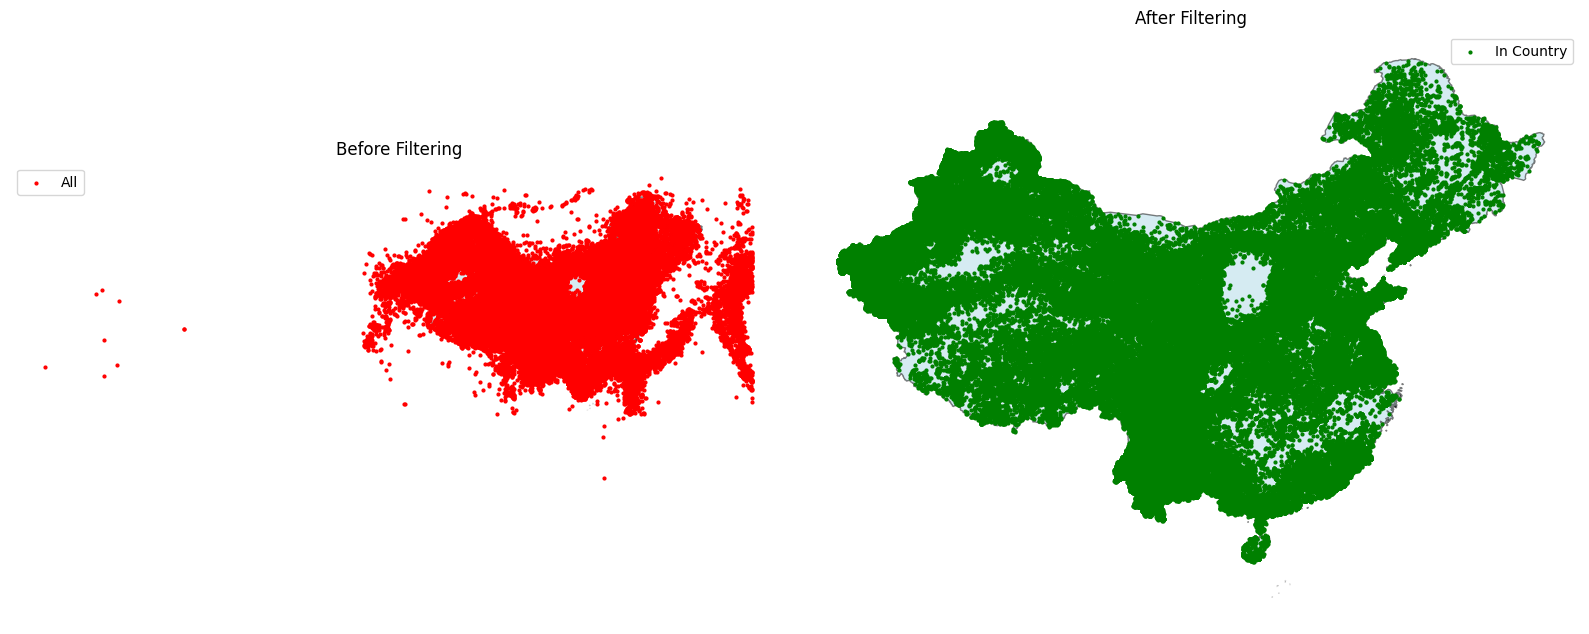

In [5]:
plot_before_after_filter(china_boundary, geo_all, geo_china)

## 4) Process Recast Catalogs

In [6]:
recast_specs = {
    'SCEDC': ('SCEDC', 'SCEDC'),
    'White': ('White', 'White'),
    'SaltonSea': ('QTMSaltonSea', 'SaltonSea'),
    'SanJacinto': ('QTMSanJacinto', 'SanJacinto'),
}

recast_data = {}
for name, (folder, stem) in recast_specs.items():
    csv_path = DATA_DIR / folder / 'raw' / f'{stem}.csv'
    metadata_path = DATA_DIR / folder / 'raw' / 'metadata.pt'
    recast_data[name] = process_recast_catalog(str(csv_path), str(metadata_path))

# Convenience aliases
_df = recast_data
df_scedc = _df['SCEDC']
df_white = _df['White']
df_saltonsea = _df['SaltonSea']
df_sanjacinto = _df['SanJacinto']

print('Recast datasets:')
for name, df in recast_data.items():
    print(f'- {name}: {df.shape}')

Recast datasets:
- SCEDC: (125668, 7)
- White: (134975, 7)
- SaltonSea: (44133, 7)
- SanJacinto: (20790, 7)


## 5) `dt` Distribution Diagnostics

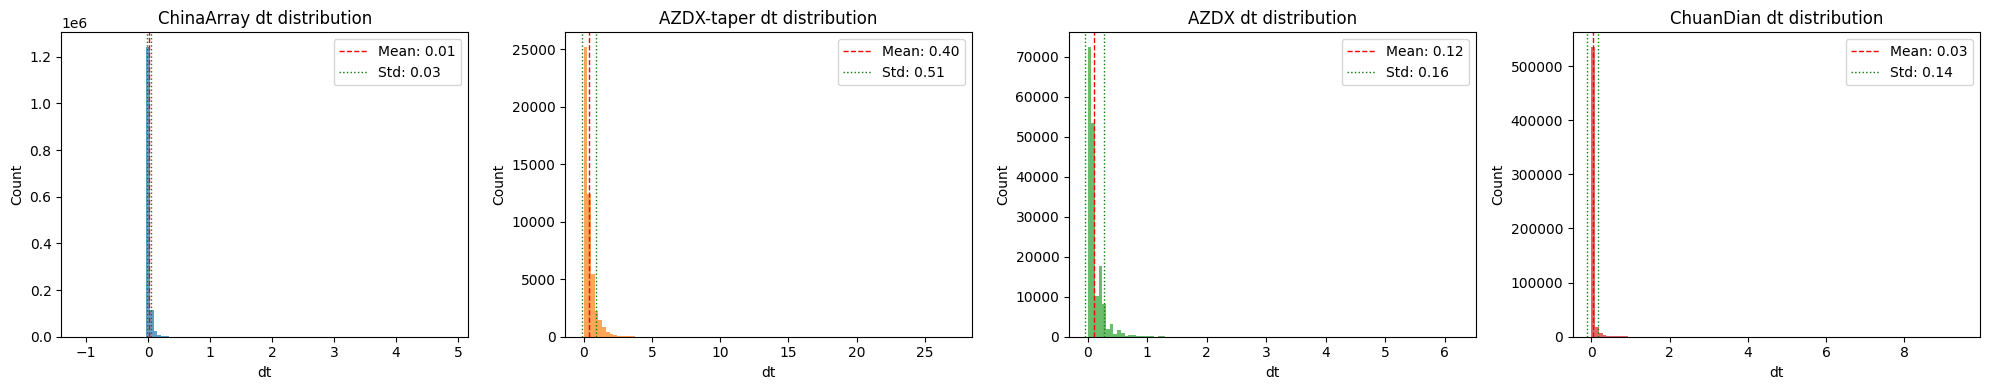

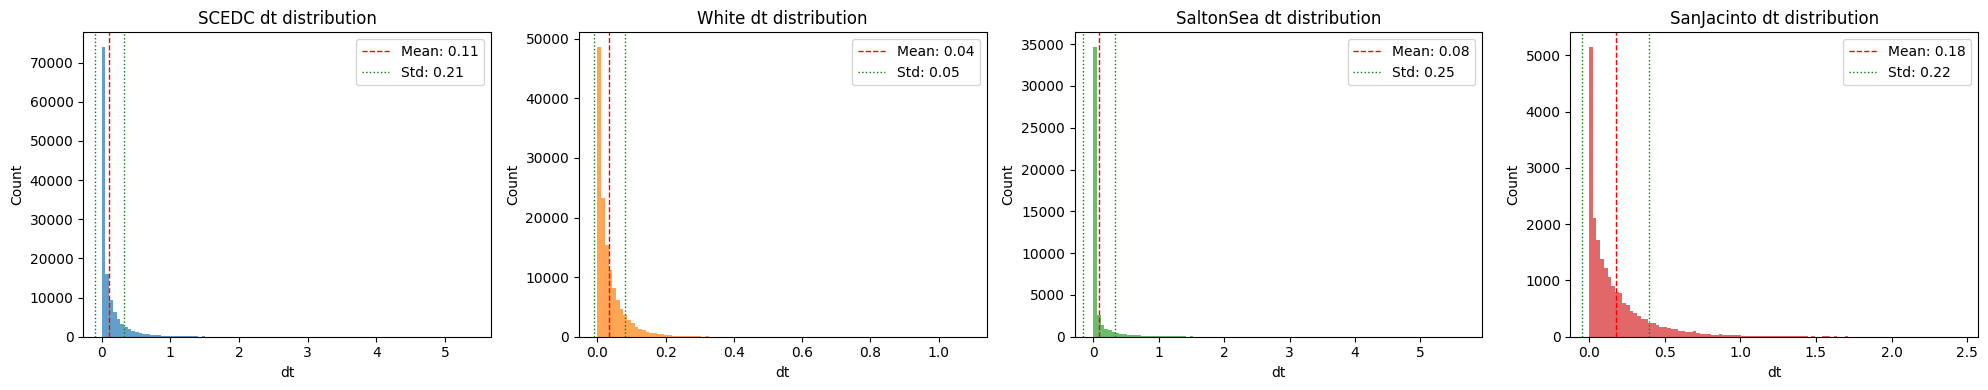

In [7]:
plot_dt_distributions(
    [df_chinaarray_processed, df_azdx_taper, df_azdx, df_chuandian],
    names=['ChinaArray', 'AZDX-taper', 'AZDX', 'ChuanDian'],
    bins=100,
)

plot_dt_distributions(
    [df_scedc, df_white, df_saltonsea, df_sanjacinto],
    names=['SCEDC', 'White', 'SaltonSea', 'SanJacinto'],
    bins=100,
    figsize=(20, 4),
)

## 6) Additional Checks and Feature Stats

CSV files found: ['White.csv', 'catalog.csv', 'processed_White.csv']
Multiple CSV files found. Using processed file: processed_White.csv
White (Mc=5.0) shape: (4, 8)
CSV files found: ['White.csv', 'catalog.csv', 'processed_White.csv']
Multiple CSV files found. Using processed file: processed_White.csv
b_lsq=2.0284, b_mlk=nan
CSV files found: ['ChinaArray.csv', 'processed_ChinaArray.csv']
Multiple CSV files found. Using processed file: processed_ChinaArray.csv
ChinaArray filtered shape: (74441, 8)
ChinaArray dt mean: 0.26303615281857545
ChinaArray dt quantiles:
0.01    0.000419
0.25    0.040410
0.50    0.143851
0.75    0.357373
0.90    0.667940
Name: dt, dtype: float64


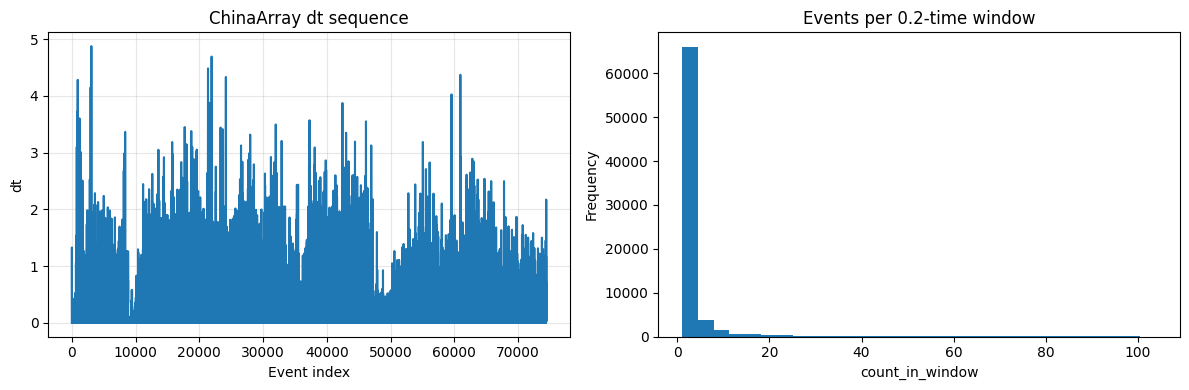

In [8]:
# Example: load filtered White catalog with higher Mc threshold
white_mc5 = load_and_filter_catalog(str(DATA_DIR / 'White'), Mc=5.0)
print('White (Mc=5.0) shape:', white_mc5.shape)

# Gutenberg-Richter related stats on White catalog
white_mc1 = load_and_filter_catalog(str(DATA_DIR / 'White'), Mc=1.0)
(
    b_lsq,
    a_lsq,
    std_gr_lsq,
    b_mlk,
    a_mlk,
    std_gr_mlk,
    dM_lsq,
    dM_mlk,
    b_std_lsq,
    b_std_mlk,
    num_mag_int,
) = calculate_magnitudes_and_features(white_mc1['Magnitude'], Mc=3.0, dMag=0.1)

print(f'b_lsq={b_lsq:.4f}, b_mlk={b_mlk:.4f}')

# ChinaArray filtered diagnostics
df_chinaarray_filtered = load_and_filter_catalog(str(DATA_DIR / 'ChinaArray'), Mc=3.0)
print('ChinaArray filtered shape:', df_chinaarray_filtered.shape)
print('ChinaArray dt mean:', df_chinaarray_filtered['dt'].mean())
print('ChinaArray dt quantiles:')
print(df_chinaarray_filtered['dt'].quantile([0.01, 0.25, 0.5, 0.75, 0.9]))

df_chinaarray_window = add_count_in_time_window(df_chinaarray_filtered, time_col='t', window=0.2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(df_chinaarray_filtered['dt'].to_numpy())
axes[0].set_title('ChinaArray dt sequence')
axes[0].set_xlabel('Event index')
axes[0].set_ylabel('dt')
axes[0].grid(True, alpha=0.3)

axes[1].hist(df_chinaarray_window['count_in_window'], bins=30)
axes[1].set_title('Events per 0.2-time window')
axes[1].set_xlabel('count_in_window')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()